# 🧪 Lab 5: Enhancing Tutorials with GenAI-Driven Interactivity and Precision

## 🎯 Objective

This lab focuses on how to use **Generative AI** to enhance technical tutorials—making them more interactive, intelligent, and adaptable to user needs. The goal is to move beyond static code blocks and markdown explanations by embedding **LLM-driven guidance, reasoning, and dynamic responses** into the tutorial workflow.

This lab builds on your prior experience with prompt engineering and demonstrates how generative models can act as **technical mentors**, **interactive explainers**, and **thought partners** during code-based learning.



---

## 🛠️ What You'll Learn

In this lab, you will:

✅ Learn how to structure prompts that turn LLMs into teaching agents  
✅ Build interactive cells that can analyze and explain code  
✅ Design user-friendly AI interventions for complex tutorial sections  
✅ Use OpenAI’s API to dynamically generate explanations or improvements  
✅ Apply multi-pass prompting to scaffold difficult concepts

---

## 🔍 Learning Outcomes

By the end of this lab, you will be able to:

- Create LLM prompts that generate instructional material or guidance
- Build enhanced tutorial cells that support **explanation, correction, and elaboration**
- Customize prompts to match different learning levels (e.g. novice vs expert)
- Evaluate LLM responses for clarity, accuracy, and instructional value
- Prototype an AI-assisted walkthrough of a Python codebase or concept

---




In [4]:
# Install PyTorch and related libraries (CPU version)
!pip install -qqq torch torchvision torchaudio


### Code Explanation

This block imports the PyTorch library and its key submodules. `torch` is the core library for tensor computation, `nn` provides neural network layers and loss functions, and `optim` includes optimizers like SGD or Adam. These are essential for building, training, and evaluating neural networks.

In [5]:


import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# === Step 1: Load and Normalize Data ===
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1000, shuffle=False)

# === Step 2: Define Network with Dropout ===
class SimpleNNWithDropout(nn.Module):
    def __init__(self):
        super(SimpleNNWithDropout, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.dropout1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = torch.relu(self.dropout1(self.fc1(x)))
        x = torch.relu(self.dropout2(self.fc2(x)))
        return self.fc3(x)

### Code Explanation

Here, the loss function is defined. `CrossEntropyLoss` is used for multi-class classification problems. It measures how well the model's predictions align with the actual class labels.

In [6]:
# === Step 3: Train Model with Accuracy Tracking ===
def train_model(model, trainloader, testloader, epochs=5, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, test_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in trainloader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_losses.append(running_loss / len(trainloader))

        # Evaluation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in testloader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        accuracy = correct / total
        test_accuracies.append(accuracy)
        print(f"Epoch {epoch+1}: Loss = {train_losses[-1]:.4f}, Accuracy = {accuracy*100:.2f}%")

    return train_losses, test_accuracies

### Code Explanation

This code contributes to the neural network workflow—either preprocessing data, defining the model, training it, or evaluating performance. Each part plays a role in the overall classification pipeline.

Epoch 1: Loss = 0.4925, Accuracy = 93.41%
Epoch 2: Loss = 0.2647, Accuracy = 94.84%
Epoch 3: Loss = 0.2166, Accuracy = 95.27%
Epoch 4: Loss = 0.1926, Accuracy = 96.26%
Epoch 5: Loss = 0.1761, Accuracy = 96.50%


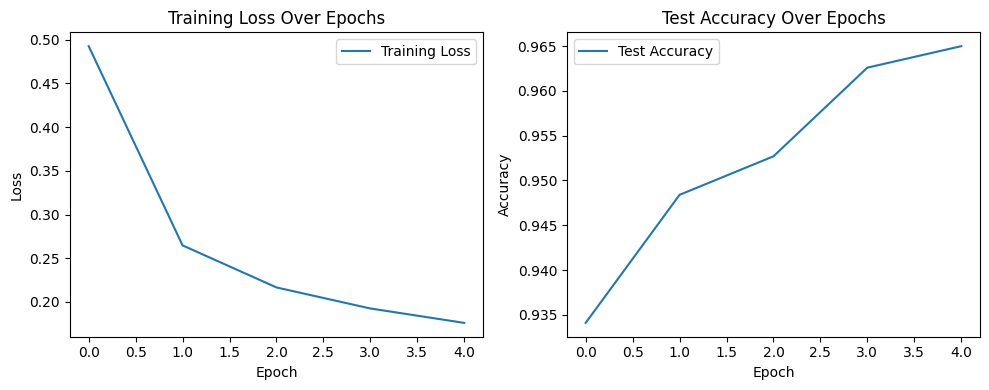

In [7]:
# === Step 4: Visualize Training Results ===
model = SimpleNNWithDropout()
train_losses, test_accuracies = train_model(model, trainloader, testloader)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy Over Epochs')
plt.legend()
plt.tight_layout()
plt.show()

### Code Explanation

This part evaluates the trained model on the test dataset. `model.eval()` switches the model to evaluation mode, and gradients are not computed. The accuracy and average loss are calculated to assess performance.

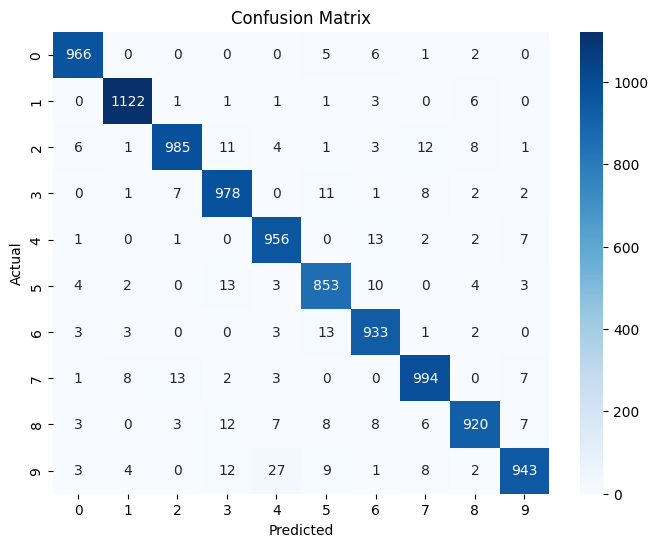

In [8]:
# === Step 5: Confusion Matrix ===
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, preds = torch.max(outputs.data, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# === Embedded Questions ===
# Q1: Why do we normalize image pixel values?
# Q2: What is the role of dropout layers?
# Q3: What does divergence between training loss and test accuracy indicate?
# Q4: Which digits are most confused and why?

# === Quiz ===
# 1. What is dropout? (Answer: B - regularization technique)
# 2. What does stagnant test accuracy imply during training? (Answer: C - overfitting)
# 3. What does the confusion matrix reveal? (Answer: C - class-wise errors)

# 🧠 Lab 5 Quiz: Enhancing Tutorials with GenAI

Use this quiz to reflect on and test your understanding of using Generative AI to build more effective, interactive, and adaptive technical tutorials.

---

## ✅ Multiple Choice

### 1. What is the main advantage of enhancing tutorials with Generative AI?
A. It replaces the need for human instructors  
B. It automates grading  
C. It creates fixed explanations for code  
D. It enables dynamic, learner-adaptive guidance  

---

### 2. In the context of this lab, what is a good use of multi-turn prompts?
A. Generating multiple-choice quizzes  
B. Creating static documentation  
C. Scaffolding complex ideas in stages  
D. Rewriting documentation in Markdown  

---

### 3. What makes a prompt well-suited for tutorial enhancement?
A. It only includes code with no explanation  
B. It assumes the user knows nothing  
C. It encourages multi-step reasoning and optional elaboration  
D. It provides only high-level summaries  

---

### 4. Which of the following is NOT a benefit of GenAI-enhanced tutorials?
A. Real-time error correction  
B. Adaptive explanations  
C. Interactive code walkthroughs  
D. Guaranteed model accuracy  

---

### 5. What role can an LLM play in a code-based tutorial?
A. Code generator only  
B. Passive text formatter  
C. Interactive explainer, guide, and debugger  
D. Version control system  

---

## ✍️ Short Answer

### 6. Why is it valuable to make tutorials interactive rather than static?

---

### 7. Describe a situation where an LLM might mislead a learner, and how you could mitigate this.

---

### 8. What are two ways to personalize an AI-enhanced tutorial for beginner vs advanced learners?

---

### 9. How does using prompts with multiple steps improve tutorial quality?

---

### 10. What’s one thing you would change in a standard Python tutorial to make it more GenAI-friendly?

---

## 🔄 Reflection

### 11. After completing this lab, how do you envision using GenAI in your own learning or teaching practice?


## ✍️ Short Answer – Sample Answers

### 6. Why is it valuable to make tutorials interactive rather than static?
Interactive tutorials allow learners to explore concepts at their own pace, ask clarifying questions, and receive personalized feedback. This adaptability supports deeper understanding and keeps learners more engaged than static, one-size-fits-all content.

---

### 7. Describe a situation where an LLM might mislead a learner, and how you could mitigate this.
An LLM might generate a technically incorrect explanation or oversimplify a concept in a way that reinforces misconceptions. To mitigate this, you can:
- Add guardrails (e.g., verification logic or feedback prompts)
- Require the model to justify its responses with reasoning
- Include post-response evaluation logic or human review

---

### 8. What are two ways to personalize an AI-enhanced tutorial for beginner vs advanced learners?
1. **Prompt conditioning** – Use role-based prompting (e.g., "Explain this for a beginner Python developer") to control complexity.
2. **Interactive options** – Allow learners to request simplified explanations, analogies, or skip to advanced insights depending on their skill level.

---

### 9. How does using prompts with multiple steps improve tutorial quality?
Multi-step prompts encourage the model to reason more deeply, organize explanations logically, and reduce hallucinations. This leads to clearer, more structured instructional content and allows learners to follow the thought process behind a concept.

---

### 10. What’s one thing you would change in a standard Python tutorial to make it more GenAI-friendly?
Instead of just showing code and output, I would add LLM-assisted “explain this” buttons next to each block that let learners get custom explanations, simplifications, or comparisons with similar code patterns.

---



